# Midterm Project: Image Classification with Machine Learning Pipeline
**Dataset** : EMNIST Letters  
**LINK**    : (https://www.kaggle.com/datasets/crawford/emnist/data)

---

###### *Auth    : Tegar Adhi Nugraha Christ During*
###### *Github  : [TegarAdh](https://github.com/TegarAdh)*


---
## 1. Dataset Preparation

- Load EMNIST Letters dataset (binary format)
- Sample 100 images per class (26 classes → 2600 total samples) for a **balanced dataset**
- Shuffle the dataset
- Visualize sample images
- Split: **80% Training / 20% Testing**

In [50]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, LeaveOneOut
from sklearn.metrics import (classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
from mlxtend.data import loadlocal_mnist

In [51]:
data_images, data_labels = loadlocal_mnist(
    images_path='dataset/emnist-letters-train-images-idx3-ubyte',
    labels_path='dataset/emnist-letters-train-labels-idx1-ubyte'
)

print(f"Total images : {len(data_images)}")
print(f"Total labels : {len(data_labels)}")

Total images : 124800
Total labels : 124800


In [52]:
data_labels = data_labels - 1   
print(f"Normalized label range: {data_labels.min()} – {data_labels.max()}")

Normalized label range: 0 – 25


In [53]:
data_images = np.array(data_images)
data_labels = np.array(data_labels)

NUM_CLASSES   = 26
SAMPLES_CLASS = 100

selected_images = []
selected_labels = []

for class_idx in range(NUM_CLASSES):
    idx = np.where(data_labels == class_idx)[0]
    if len(idx) >= SAMPLES_CLASS:
        chosen = np.random.choice(idx, SAMPLES_CLASS, replace=False)
        selected_images.append(data_images[chosen])
        selected_labels.append(data_labels[chosen])
    else:
        print(f"[WARNING] Class {class_idx} ({chr(class_idx+97)}) has only {len(idx)} samples!")

X_subset = np.vstack(selected_images)   
y_subset = np.hstack(selected_labels)   

print(f"\nX_subset shape : {X_subset.shape[0]}")
print(f"y_subset shape : {y_subset.shape[0]}")


X_subset shape : 2600
y_subset shape : 2600


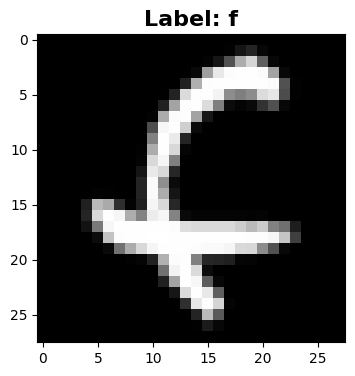

In [54]:
idx = 563

img = X_subset[idx].reshape(28, 28).T
label = chr(y_subset[idx] + 97)

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')

plt.title(f'Label: {label}', fontsize=16, fontweight='bold')
plt.axis()

plt.show()

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset   
)

print(f"Training set   : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X_subset)*100:.0f}%)")
print(f"Test set       : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X_subset)*100:.0f}%)")

Training set   : 2080 samples  (80%)
Test set       : 520 samples  (20%)


In [56]:
loo = LeaveOneOut()

svm_loo = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

print("\nRunning LOOCV on training set (this may take a while)...")
loo_scores = cross_val_score(
    svm_loo,
    X_train,   # hasil HOG dari training set
    y_train,
    cv=loo,
    scoring='accuracy',
    n_jobs=-1      # paralel untuk mempercepat
)

print(f"LOOCV Accuracy (training set): {loo_scores.mean()*100:.2f}% ± {loo_scores.std()*100:.2f}%")


Running LOOCV on training set (this may take a while)...
LOOCV Accuracy (training set): 73.70% ± 44.03%


---
## 2. Feature Extraction 

In [57]:
HOG_ORIENTATIONS    = 8       # default: 9
HOG_PIXELS_PER_CELL = (4, 4)  # default: (8, 8) 
HOG_CELLS_PER_BLOCK = (2, 2)  # default: (3, 3)
HOG_BLOCK_NORM      = 'L2'

print(f"HOG orientations    : {HOG_ORIENTATIONS}")
print(f"HOG pixels_per_cell : {HOG_PIXELS_PER_CELL}")
print(f"HOG cells_per_block : {HOG_CELLS_PER_BLOCK}")
print(f"HOG block_norm      : {HOG_BLOCK_NORM}")

HOG orientations    : 8
HOG pixels_per_cell : (4, 4)
HOG cells_per_block : (2, 2)
HOG block_norm      : L2


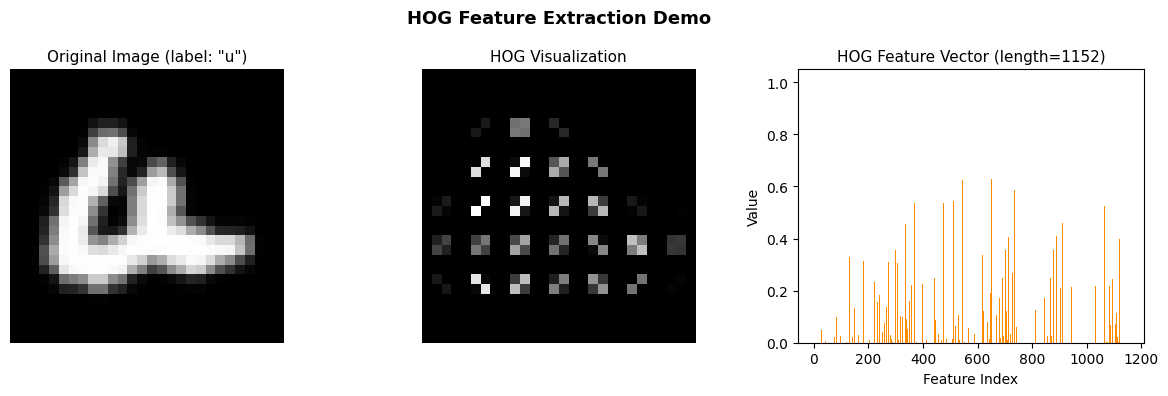


HOG feature Vector: 1152


In [58]:
sample_img = X_train[0].reshape(28, 28)
sample_label = chr(y_train[0] + 97)

hog_feature, hog_img = hog(
    sample_img,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm=HOG_BLOCK_NORM,
    visualize=True
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_img.T, cmap='gray')
axes[0].set_title(f'Original Image (label: "{sample_label}")', fontsize=11)
axes[0].axis('off')

axes[1].imshow(hog_img.T, cmap='gray')
axes[1].set_title('HOG Visualization', fontsize=11)
axes[1].axis('off')

axes[2].bar(range(len(hog_feature)), hog_feature, color='darkorange', linewidth=0.3)
axes[2].set_title(f'HOG Feature Vector (length={len(hog_feature)})', fontsize=11)
axes[2].set_xlabel('Feature Index')
axes[2].set_ylabel('Value')

plt.suptitle('HOG Feature Extraction Demo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nHOG feature Vector: {hog_feature.shape[0]}")

In [59]:
def extract_hog_features(images, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(3, 3), block_norm='L2'):
    """Extract HOG features for a batch of flattened 28x28 images."""
    features = []
    for img in images:
        feat = hog(
            img.reshape(28, 28),
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm
        )
        features.append(feat)
    return np.array(features)

In [32]:
X_train_hog = extract_hog_features(
    X_train,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm=HOG_BLOCK_NORM
)

X_test_hog = extract_hog_features(
    X_test,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm=HOG_BLOCK_NORM
)

print(f"X_train_hog shape : {X_train_hog.shape}")
print(f"X_test_hog  shape : {X_test_hog.shape}")
print(f"\nFeature vector length per image: {X_train_hog.shape[1]}")

X_train_hog shape : (2080, 1152)
X_test_hog  shape : (520, 1152)

Feature vector length per image: 1152


---
## 3. Classification 

### Grid Search Parameter Grid:
| Parameter | Values Searched |
|---|---|
| `kernel` | `linear`, `rbf`, `poly` |
| `C` (Regularization) | `0.1`, `1`, `10`, `100` |
| `gamma` | `scale`, `auto` |

In [60]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto']
}

print("Parameter grid for Grid Search:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)
print(f"\nTotal combinations: {total_combinations}")

Parameter grid for Grid Search:
  kernel: ['linear', 'rbf', 'poly']
  C: [0.1, 1, 10, 100]
  gamma: ['scale', 'auto']

Total combinations: 24


In [61]:
svm = SVC(random_state=42)
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=3,           
    n_jobs=-1,      
    verbose=2,
    scoring='accuracy'
)

print("Starting Grid Search...")
grid_search.fit(X_train_hog, y_train)
print("\nGrid Search complete!")


Starting Grid Search...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Grid Search complete!


In [63]:
print("BEST PARAMETERS FROM GRID SEARCH")
for param, value in grid_search.best_params_.items():
    print(f"  {param:10s}: {value}")
print(f"\nBest CV Accuracy: {grid_search.best_score_*100:.2f}%")

BEST PARAMETERS FROM GRID SEARCH
  C         : 10
  gamma     : scale
  kernel    : rbf

Best CV Accuracy: 81.10%


In [64]:
best_svm = grid_search.best_estimator_
print(f"Best SVM model: {best_svm}")

Best SVM model: SVC(C=10, random_state=42)


In [65]:
y_train_pred = best_svm.predict(X_train_hog)
train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy  : {train_accuracy*100:.2f}%")
print(f"Training Precision : {precision_score(y_train, y_train_pred, average='macro', zero_division=0)*100:.2f}%  (macro)")
print(f"Training Recall    : {recall_score(y_train, y_train_pred, average='macro', zero_division=0)*100:.2f}%  (macro)")
print(f"Training F1-Score  : {f1_score(y_train, y_train_pred, average='macro', zero_division=0)*100:.2f}%  (macro)")

Training Accuracy  : 100.00%
Training Precision : 100.00%  (macro)
Training Recall    : 100.00%  (macro)
Training F1-Score  : 100.00%  (macro)


---
## 4. Evaluation
- Accuracy
- Precision (macro)
- Recall (macro)
- F1-Score (macro)
- Confusion Matrix

In [66]:
y_test_pred = best_svm.predict(X_test_hog)

In [67]:
label_names = [chr(i + 97) for i in range(NUM_CLASSES)]

print("\nDetailed Classification Report – TEST SET")
print("=" * 60)
print(classification_report(
    y_test, y_test_pred,
    target_names=label_names,
    zero_division=0
))


Detailed Classification Report – TEST SET
              precision    recall  f1-score   support

           a       0.74      0.70      0.72        20
           b       0.89      0.85      0.87        20
           c       0.87      1.00      0.93        20
           d       0.84      0.80      0.82        20
           e       0.85      0.85      0.85        20
           f       0.82      0.70      0.76        20
           g       0.70      0.80      0.74        20
           h       0.76      0.80      0.78        20
           i       0.74      0.70      0.72        20
           j       0.90      0.95      0.93        20
           k       1.00      0.90      0.95        20
           l       0.68      0.75      0.71        20
           m       0.86      0.90      0.88        20
           n       0.75      0.75      0.75        20
           o       0.74      1.00      0.85        20
           p       0.89      0.85      0.87        20
           q       0.79      0.55     

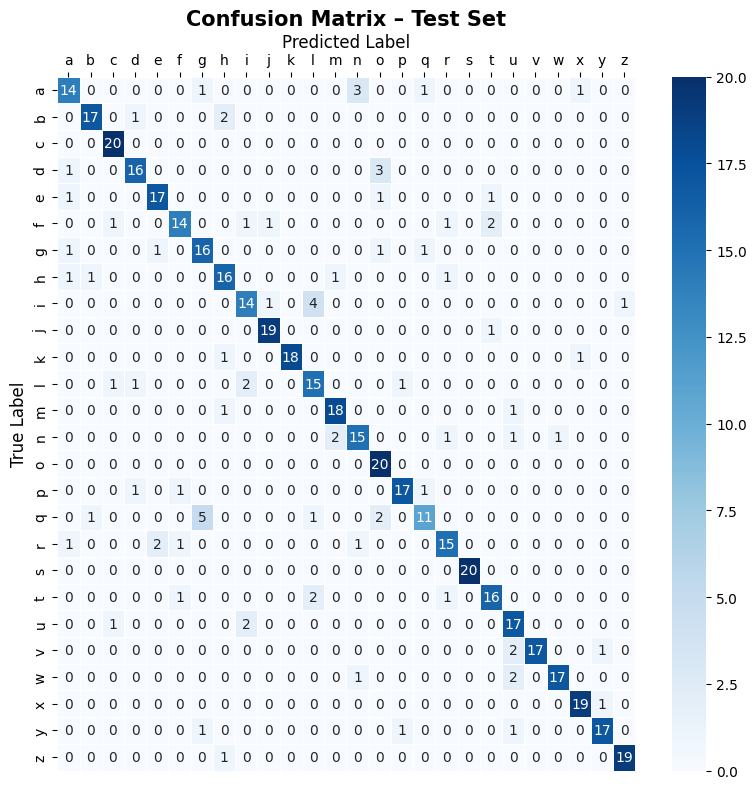

In [68]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.5
)
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.title('Confusion Matrix – Test Set', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

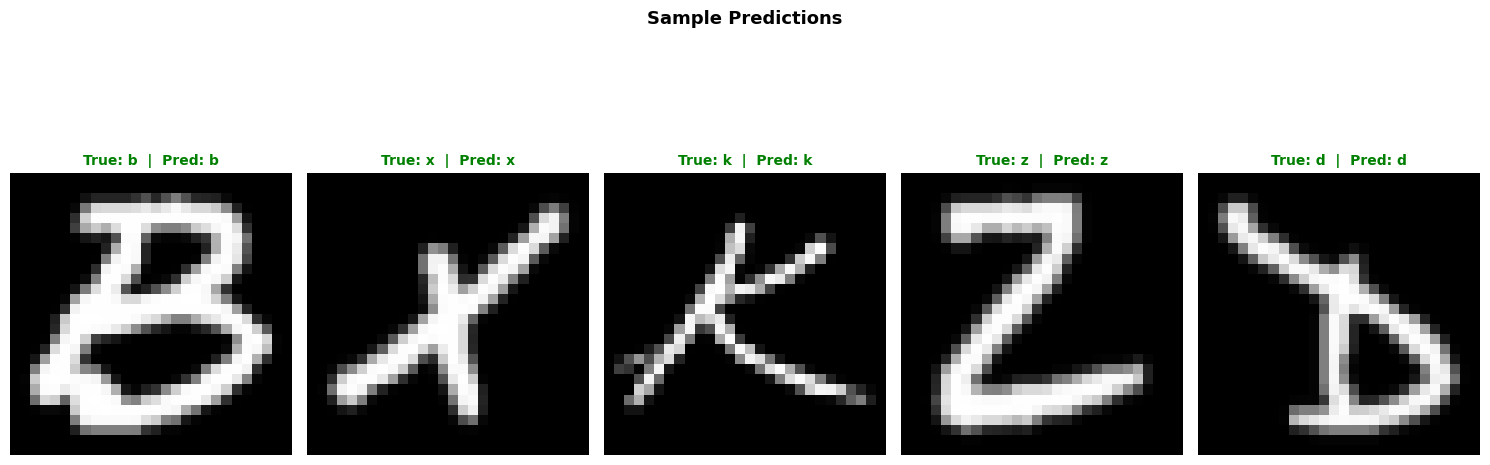

In [71]:
sample_indices = random.sample(range(len(X_test)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img        = X_test[idx].reshape(28, 28).T
    true_label = chr(y_test[idx] + 97)
    pred_label = chr(y_test_pred[idx] + 97)
    correct    = true_label == pred_label

    axes[i].imshow(img, cmap='gray')
    color = 'green' if correct else 'red'
    axes[i].set_title(
        f'True: {true_label}  |  Pred: {pred_label}',
        color=color, fontsize=10, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()